# Initial Project Applied Machnie Learning Filip Niewczas 

In [2]:
%pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 4.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
# Load the CSV file
df = pd.read_csv(file_path)

# Reset indices to 0, 1, 2, ...
df.reset_index(drop=True, inplace=True)

print(df.head())

    9085    194843.03
0  34480   54105.6450
1   3001    6670.2476
2  34119   30869.5860
3  22100   78185.8000
4  12532  244574.8800


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.inspection import permutation_importance


In [4]:

test_clas = pd.read_csv('AppML_InitialProject_test_classification.csv')
test_reg = pd.read_csv('AppML_InitialProject_test_regression.csv')
train_sample = pd.read_csv('AppML_InitialProject_train.csv')
data_for_clastering = pd.read_csv('SDSS-Gaia_5950stars.csv')
 

In [5]:


print(train_sample.head()) 
# p_Truth_isElectron is the target variable - binary 0/1 
print(train_sample.describe())
# with the mean of 0.21 so 21% of the data is 1 and 79% is 0 <- bad balaced, TODO check MSE with more balanced 
# TODO SHAP VALUES CHECKING 
# TODO after checking the data, upload the dataset


   averageInteractionsPerCrossing   p_Rhad1    p_Rhad      p_f3   p_weta2  \
0                           55.50 -0.002390 -0.003614  0.000744  0.010088   
1                           33.50 -0.009279 -0.010666  0.003784  0.011625   
2                           35.50  0.002806  0.013643  0.025505  0.010330   
3                           40.49 -0.001910  0.000044  0.000176  0.010323   
4                           52.50  0.013779 -0.002106  0.010156  0.010096   

     p_Rphi    p_Reta  p_Eratio      p_f1  p_TRTPID  ...  pX_E7x11_Lr2  \
0  0.947685  0.983722  0.969448  0.355275 -0.030026  ...     27951.328   
1  0.922366  0.955934  0.918366  0.397633  0.335419  ...     34642.820   
2  0.969845  0.945576  0.921568  0.077971  0.517517  ...     88892.890   
3  0.923816  0.888029  0.000000  0.000000  0.133801  ...     39768.450   
4  0.899883  0.717177  0.782584  0.253658 -0.044038  ...     15531.818   

   pX_E7x11_Lr3  pX_E7x7_Lr0  pX_E7x7_Lr1  p_pt_track     p_eta     p_phi  \
0    473.046360

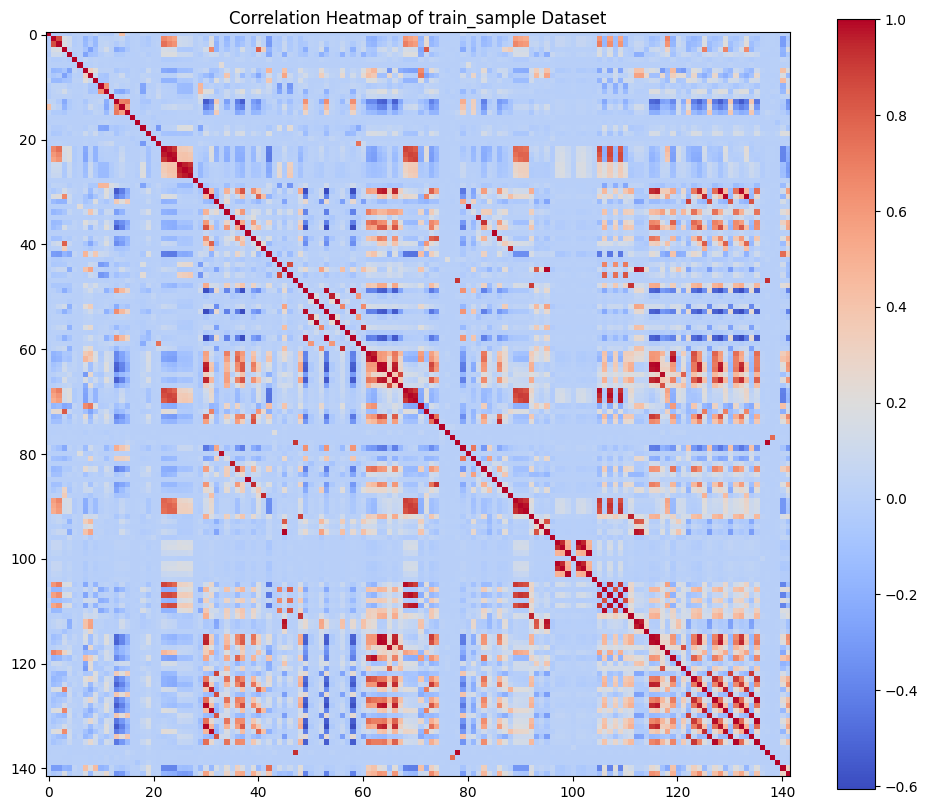

In [7]:
# Compute the correlation matrix
correlation_matrix = train_sample.corr()

# Plot the heatmap using Matplotlib
plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.title("Correlation Heatmap of train_sample Dataset")
plt.show()


In [9]:



from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
import xgboost as xgb

# Dane wejściowe
X_features = train_sample.drop(columns=['p_Truth_isElectron'])
y_target = train_sample['p_Truth_isElectron']

# Podział na trening i test
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.3, random_state=42)

# Model z najlepszymi parametrami
best_clf = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    colsample_bytree=0.8,
    learning_rate=0.2,
    max_depth=7,
    n_estimators=200,
    subsample=1.0,
    random_state=42
)

# Trening
best_clf.fit(X_train, y_train)

# Predykcja klas
y_pred = best_clf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Predykcja prawdopodobieństw i logloss
y_pred_proba = best_clf.predict_proba(X_test)[:, 1]
print("LogLoss (XGBoost):", log_loss(y_test, y_pred_proba))


/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:24:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Test Accuracy: 0.9828333333333333
LogLoss (XGBoost): 0.05275979331663289


In [11]:
%pip install shap


  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.2/554.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 10.0 MB/s eta 0:00:00a 0:00:01
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.1/31.1 MB 10.4 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|===================| 125947/126000 [32:58<00:00]        

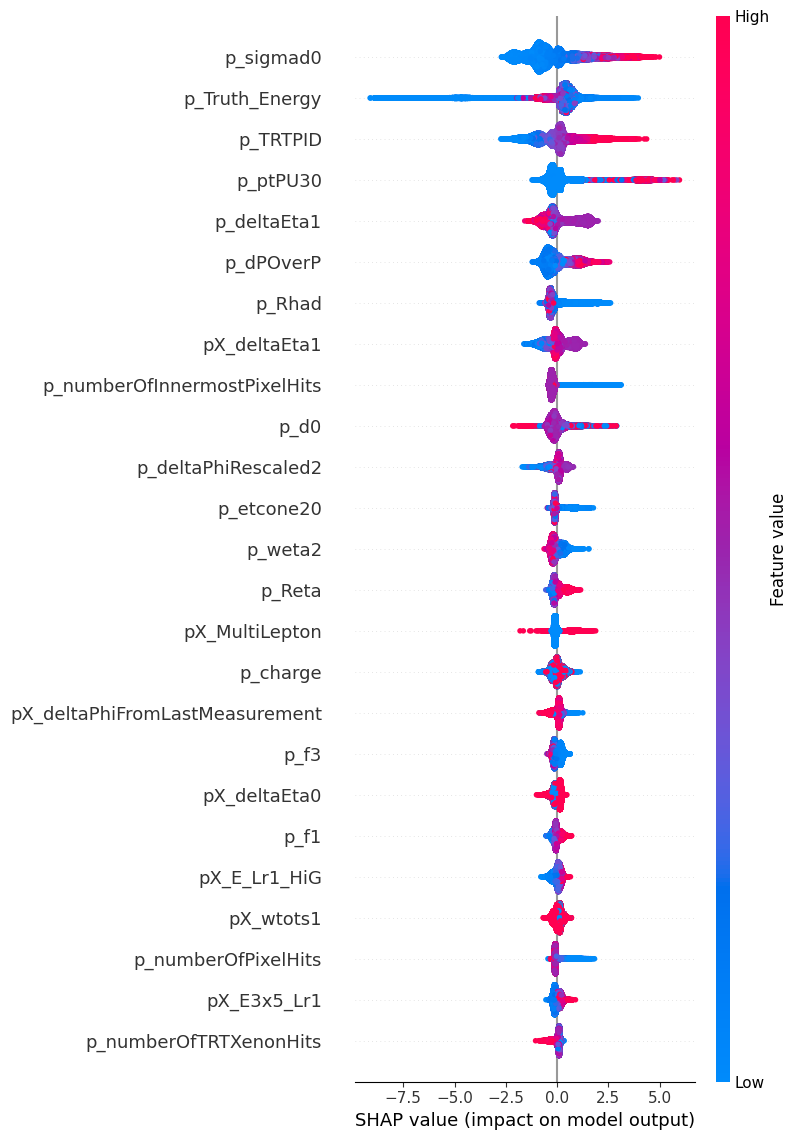

In [12]:
electron_mask = train_sample['p_Truth_isElectron'] == 1
X = train_sample.loc[electron_mask, top7_features]
y = train_sample.loc[electron_mask, 'p_truth_Energy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
shap_abs_mean = np.abs(shap_values.values).mean(axis=0)

# TOP 25 
top25_indices = np.argsort(shap_abs_mean)[::-1][:25]
top25_features = X_train.columns[top25_indices].tolist()

print("Top 25 SHAP:")
print(top25_features)

Top 25 SHAP:
['p_sigmad0', 'p_Truth_Energy', 'p_TRTPID', 'p_ptPU30', 'p_deltaEta1', 'p_dPOverP', 'p_Rhad', 'pX_deltaEta1', 'p_numberOfInnermostPixelHits', 'p_d0', 'p_deltaPhiRescaled2', 'p_etcone20', 'p_weta2', 'p_Reta', 'pX_MultiLepton', 'p_charge', 'pX_deltaPhiFromLastMeasurement', 'p_f3', 'pX_deltaEta0', 'p_f1', 'pX_E_Lr1_HiG', 'pX_wtots1', 'p_numberOfPixelHits', 'pX_E3x5_Lr1', 'p_numberOfTRTXenonHits']


In [9]:
top7_indices = np.argsort(shap_abs_mean)[::-1][:7]
top7_features = ['p_sigmad0', 'p_Truth_Energy', 'p_TRTPID', 'p_ptPU30', 'p_deltaEta1', 'p_dPOverP', 'p_Rhad', 'pX_deltaEta1']

print("Top 7 SHAP:", top7_features)

# 2. Filtrujemy tylko elektrony z train_sample
electron_mask = train_sample['p_Truth_isElectron'] == 1
X = train_sample.loc[electron_mask, top7_features]
y = train_sample.loc[electron_mask, 'p_Truth_Energy']

NameError: name 'np' is not defined

In [12]:
train_sample = pd.read_csv("AppML_InitialProject_train.csv")
test_reg = pd.read_csv("AppML_InitialProject_test_regression.csv")

top_features = ['p_sigmad0', 
                #'p_Truth_Energy',  # NIE UŻYWAJ targetu jako cechy!
                'p_TRTPID', 'p_ptPU30', 'p_deltaEta1', 
                'p_dPOverP', 'p_Rhad', 'pX_deltaEta1']

X_train = train_sample[top_features]
y_train = train_sample["p_Truth_Energy"]


In [13]:
from xgboost import XGBRegressor

reg = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
reg.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [14]:
import pandas as pd
X_test = test_reg[top_features]
y_pred = reg.predict(X_test)

# Save predictions to CSV
# Zapisz predykcje do pliku (bez nagłówków, z indeksami 0..N-1)
submission = pd.DataFrame({
    'prediction': y_pred
})
submission.to_csv("Regression_FilipNiewczas_XGBoost1.csv", index=True, header=False)

# Zapisz listę cech (jedna per linia, bez nagłówków)
pd.Series(top_features).to_csv("Regression_FilipNiewczas_XGBoost1_VariableList.csv", index=False, header=False)

In [15]:
from sklearn.metrics import mean_absolute_error

# Przewidujemy na zbiorze treningowym (lub części, jak wolisz)
y_train_pred = reg.predict(X_train)

# Liczymy MAE
mae = mean_absolute_error(y_train, y_train_pred)
print("MAE na zbiorze treningowym:", mae)


MAE na zbiorze treningowym: 16346.690475377918


In [20]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 1. Wczytanie danych
train_sample = pd.read_csv("AppML_InitialProject_train.csv")
test_reg = pd.read_csv("AppML_InitialProject_test_regression.csv")

# 2. Filtrowanie tylko elektronów
train_sample = train_sample[train_sample["p_Truth_isElectron"] == 1]

# 3. Lista wybranych cech (SHAP top 7)
top_features = ['p_sigmad0', 'p_TRTPID', 'p_ptPU30', 'p_deltaEta1', 
                'p_dPOverP', 'p_Rhad', 'pX_deltaEta1',  'p_numberOfInnermostPixelHits','p_d0', 'p_deltaPhiRescaled2', 'p_etcone20', 'p_weta2' ]

# 4. Przygotowanie danych
X_train = train_sample[top_features]
y_train = train_sample["p_Truth_Energy"]

# 5. Trening modelu
reg = XGBRegressor(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
reg.fit(X_train, y_train)

# 6. Predykcja na zbiorze treningowym – do oceny jakości
y_train_pred = reg.predict(X_train)
nonzero_mask = y_train != 0
relative_mae = np.mean(np.abs((y_train_pred[nonzero_mask] - y_train[nonzero_mask]) / y_train[nonzero_mask]))
print("Relative MAE na zbiorze treningowym:", relative_mae)

# 7. Predykcja na zbiorze testowym
X_test = test_reg[top_features]
y_pred = reg.predict(X_test)

# # 8. Zapis predykcji (dla solution checker)
# submission = pd.DataFrame({'prediction': y_pred})
# submission.to_csv("Regression_FilipNiewczas_XGBoost1.csv", index=True, header=False)

# # 9. Zapis listy cech
# pd.Series(top_features).to_csv("Regression_FilipNiewczas_XGBoost1_VariableList.csv", index=False, header=False)



Relative MAE na zbiorze treningowym: 0.335443370286296
